Device: cuda

── Generating synthetic recordings ──
  Train recordings: 1400  Val: 300  Test: 300

── Building window datasets ──
  Dataset: 86800 windows  (5576 positive = 6.4%)
  Dataset: 18600 windows  (580 positive = 3.1%)
  Dataset: 18600 windows  (632 positive = 3.4%)

── Training ──
  Trainable parameters: 5,058,626

Epoch 001/50  | train loss=0.0783  det=0.0252  reg=0.0266  acc=0.957  t_mae=0.3100  || val loss=0.0111  det=0.0106  acc=0.998  t_mae=0.0275
Epoch 002/50  | train loss=0.0718  det=0.0235  reg=0.0241  acc=0.962  t_mae=0.2791  || val loss=0.0120  det=0.0080  acc=0.998  t_mae=0.0603
Epoch 003/50  | train loss=0.0729  det=0.0240  reg=0.0244  acc=0.961  t_mae=0.2825  || val loss=0.0143  det=0.0112  acc=0.997  t_mae=0.0583
Epoch 004/50  | train loss=0.0711  det=0.0237  reg=0.0237  acc=0.962  t_mae=0.2758  || val loss=0.0118  det=0.0116  acc=0.998  t_mae=0.0191
Epoch 005/50  | train loss=0.0703  det=0.0236  reg=0.0233  acc=0.962  t_mae=0.2751  || val loss=0.0093  det=0.0087

(<Figure size 1400x1120 with 4 Axes>,
 array([<Axes: ylabel='Temperature'>, <Axes: ylabel='Pressure'>,
        <Axes: ylabel='Salinity'>,
        <Axes: xlabel='Timestep', ylabel='Oxygen'>], dtype=object))

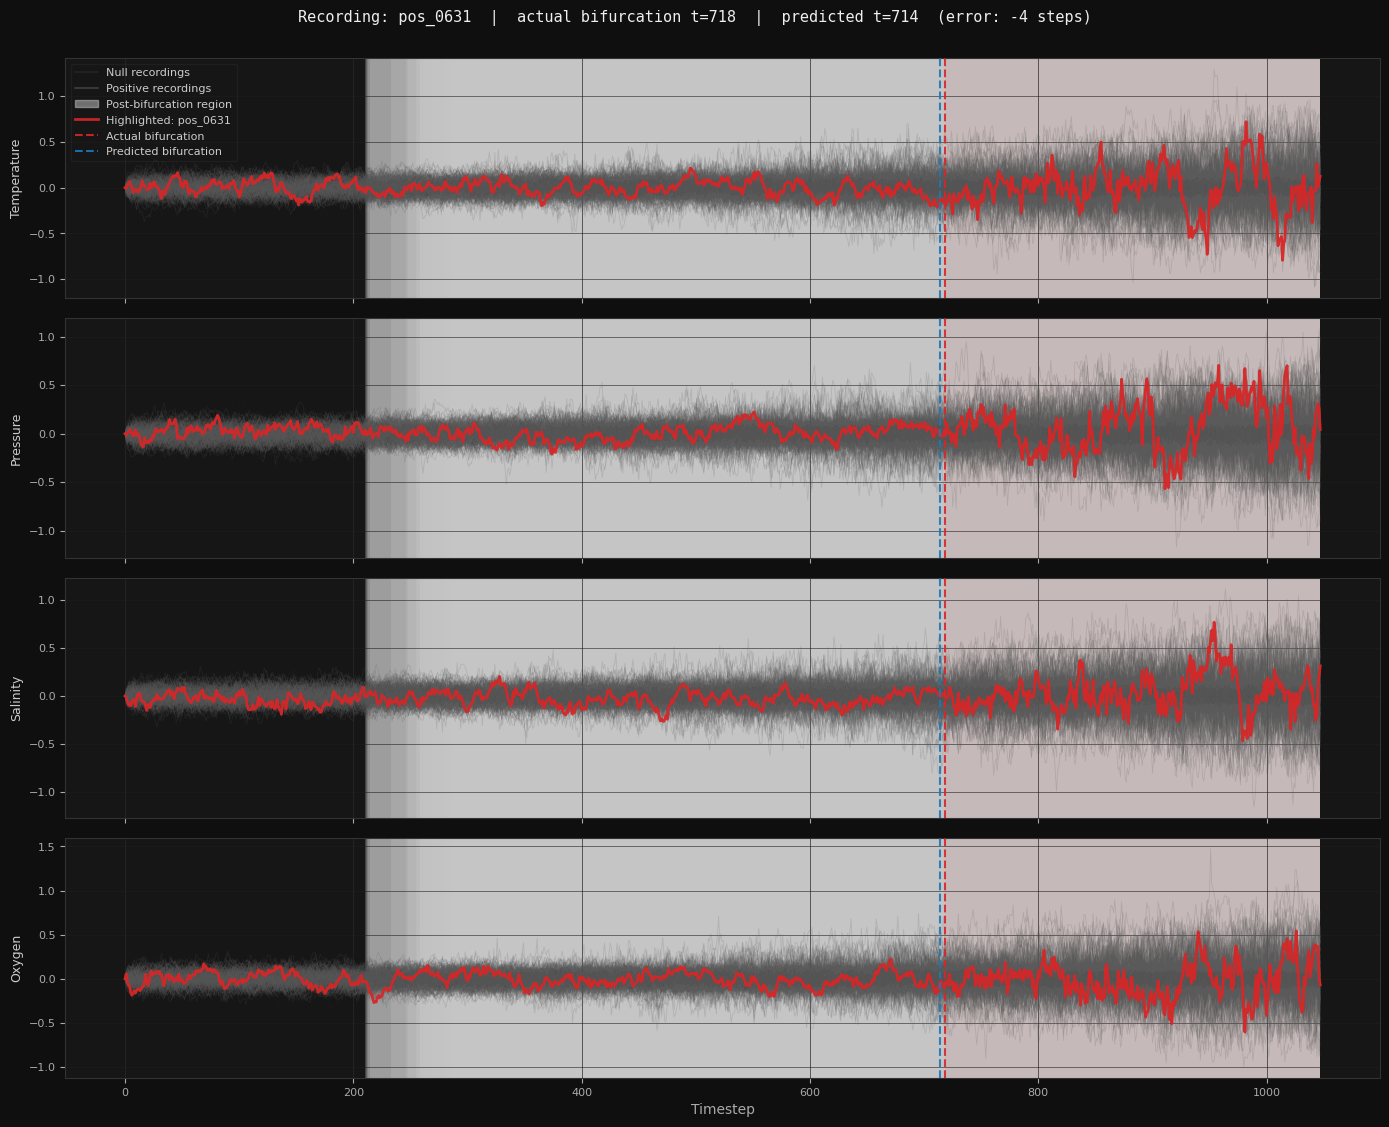

In [1]:
"""
Bifurcation Detection — Regression Training Pipeline & Streaming Deployment
============================================================================

Model outputs TWO heads per window:
  • p_bifurc  : P(a bifurcation exists in this window)          — binary [0,1]
  • t_bifurc  : normalised timestep of bifurcation ∈ [0,1]      — regression
                (only meaningful / penalised when p_bifurc > 0)

Why two heads?
  Null windows have no meaningful regression target.  Penalising the timestep
  head on null samples would force the network to predict an arbitrary number,
  corrupting the gradient signal.  Instead the regression loss is gated by
  whether the window actually contains a bifurcation.

Normalised timestep convention
  t_norm = (bifurcation_absolute_timestep − window_start) / window_length
  So t_norm=0.0 → bifurcation at the very start of the window
     t_norm=1.0 → bifurcation at the very end

Streaming deployment
  A rolling window strides across incoming data. Each stride produces:
    • updated p_bifurc estimate
    • predicted absolute timestep of the bifurcation
  An alert fires when p_bifurc passes a configurable threshold, with
  hysteresis to avoid duplicate alerts.
"""

import numpy as np
import torch
from torch.utils.data import DataLoader

from bi_plot import plot_recordings
from bi_data_sim import make_synthetic_recordings
from bi_data_struct import recording_level_split, BifurcationWindowDataset
from bi_model import BifurcationRegressor, train,collate_nan_safe, evaluate, GatedBifurcationLoss
from bi_stream import StreamingBifurcationDetector

# ──────────────────────────────────────────────────────────────────────────────
# Demo
# ──────────────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

# ── 1. Generate recordings and split by recording ─────────────────────
print("── Generating synthetic recordings ──")
all_recordings = make_synthetic_recordings(
    n_null=1000, n_positive=1000, num_params=4, depth=75, time_len=1048,seed=np.random.randint(1e6,size=1)
)
train_recs, val_recs, test_recs = recording_level_split(all_recordings)
print(f"  Train recordings: {len(train_recs)}  Val: {len(val_recs)}  Test: {len(test_recs)}\n")

# ── 2. Build window datasets ──────────────────────────────────────────
print("── Building window datasets ──")
WINDOW = 64
STRIDE = 16

train_ds = BifurcationWindowDataset(train_recs, window_len=WINDOW, stride=STRIDE, precursor_steps=64)
val_ds   = BifurcationWindowDataset(val_recs,   window_len=WINDOW, stride=STRIDE)
test_ds  = BifurcationWindowDataset(test_recs,  window_len=WINDOW, stride=STRIDE)
print()

# ── 3. Build and train model ──────────────────────────────────────────
print("── Training ──")
model = BifurcationRegressor(num_params=4).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Trainable parameters: {total_params:,}\n")

model = train(
    model, train_ds, val_ds, device,
    epochs=50,       # increase for real training
    batch_size=64,
    patience=10,
    save_path=None,  # set a path to save checkpoints
)

# ── 4. Test set evaluation ────────────────────────────────────────────
print("\n── Test set evaluation ──")
test_loader = DataLoader(
    test_ds, batch_size=64, collate_fn=collate_nan_safe
)
criterion = GatedBifurcationLoss()
test_metrics = evaluate(model, test_loader, criterion, device)
print(
    f"  test loss={test_metrics['loss']:.4f}  "
    f"det_acc={test_metrics['det_acc']:.3f}  "
    f"timing_mae={test_metrics['timing_mae']:.4f} (normalised)"
)
print(
    f"  timing_mae in timesteps ≈ {test_metrics['timing_mae'] * WINDOW:.1f} / {WINDOW}"
)

# ── 5. Streaming demo ─────────────────────────────────────────────────
print("\n── Streaming demo ──")
detector = StreamingBifurcationDetector(
    model, window_len=WINDOW, stride=STRIDE,
    threshold=0.55, cooldown_steps=32, ema_alpha=0.4, device=device,
)

# Pick a positive test recording and stream it in stride-sized chunks
pos_recs = [r for r in test_recs if r.is_positive]
if pos_recs:
    rec = pos_recs[0]
    print(f"  Streaming recording '{rec.recording_id}'  "
          f"(true bifurcation at t={rec.bifurcation_t}, "
          f"total T={rec.time_len})")

    for t in range(0, rec.time_len, STRIDE):
        chunk = rec.data[:, :, t : t + STRIDE]
        if chunk.shape[2] == 0:
            print("warning chunk wrong shape!")
            break
        alerts = detector.push(chunk)
        for alert in alerts:
            lead = alert.steps_until_bifurc
            lead_str = f"{lead:+d} steps" if lead >= 0 else f"{abs(lead)} steps AFTER"
            print(
                f"  🚨 ALERT  t={alert.absolute_timestep:4d}  "
                f"p={alert.p_bifurcation:.3f}  "
                f"predicted_t={alert.predicted_bifurc_t}  "
                f"lead={lead_str}"
            )
else:
    print("  (No positive recordings in test split — increase n_positive or use a fixed seed)")

print(f"Highlight: {rec.recording_id}")
print(f"  Actual bifurcation    : t={rec.bifurcation_t}")
print(f"  Prediction bifurcation  : t={alert.predicted_bifurc_t}")

plot_recordings(
    recordings=test_recs,#recordings,
    highlight=rec,#highlight,
    predicted_t=alert.predicted_bifurc_t,
    depth_summary="mean",
    param_names=["Temperature", "Pressure", "Salinity", "Oxygen"],
    save_path="bifurcation_plot.png",
)
